# Diffusion Models From Scratch

## 1. Why Diffusion Comes After VAEs and GANs

VAEs generate by sampling from a learned latent distribution.

GANs generate by training a Generator against a Discriminator.

Diffusion models use another idea:

> Gradually destroy structure by adding noise, then train a neural network to reverse that corruption.

The model learns generation as a sequence of denoising operations.

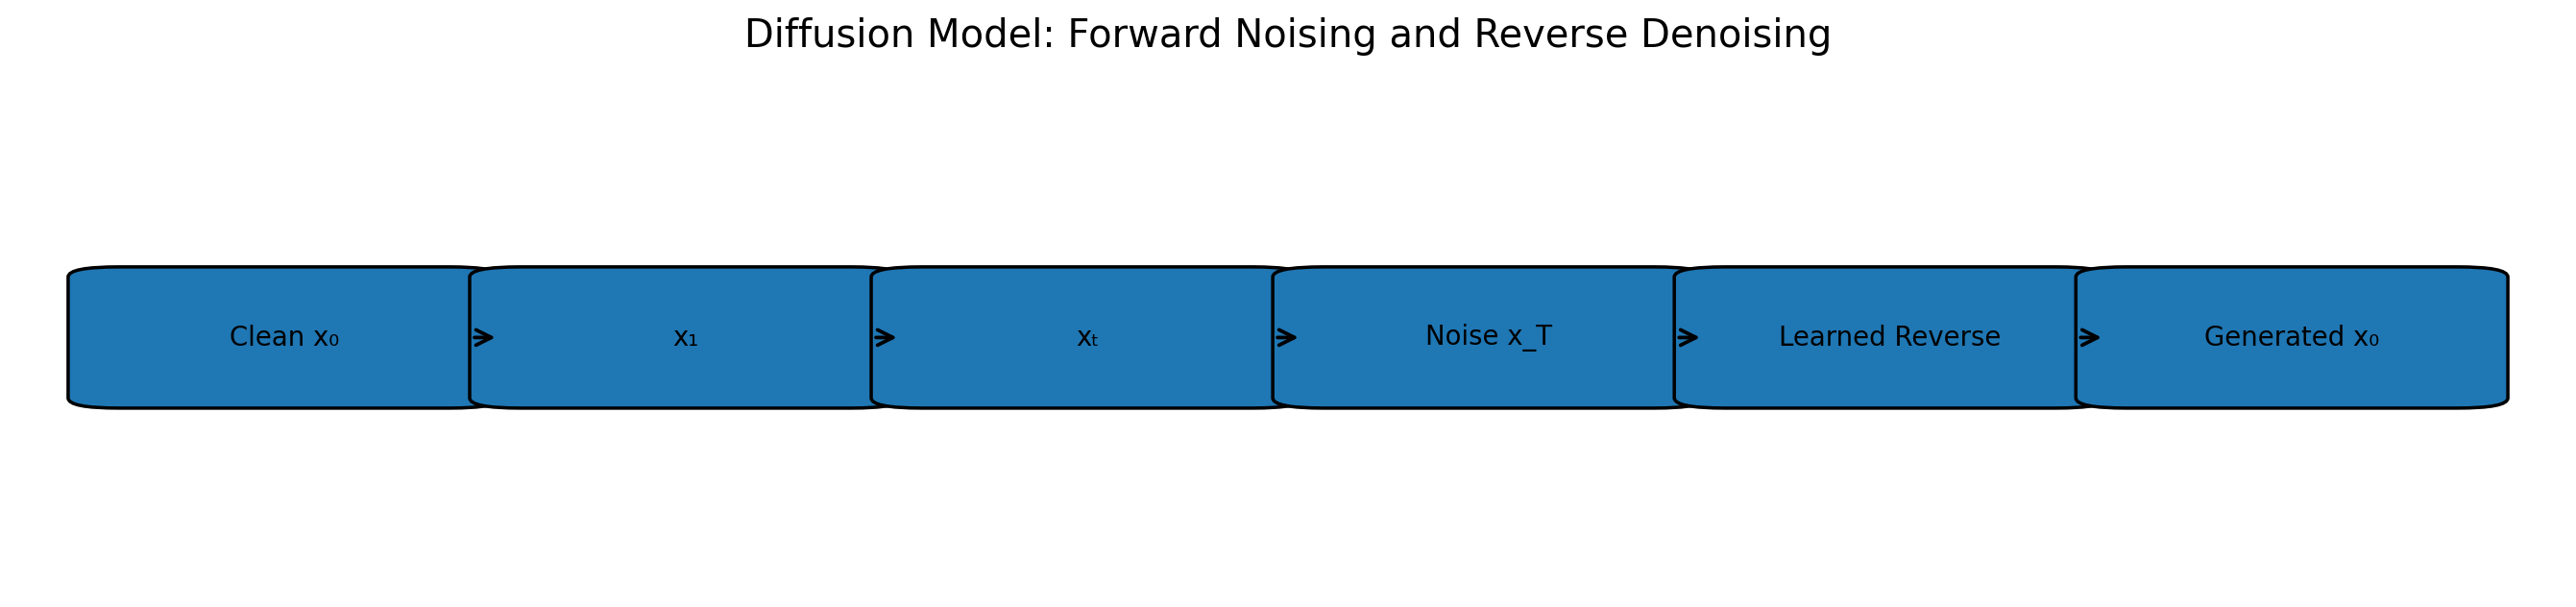

## 2. Learning Objectives

By the end of this notebook, you should be able to:

- explain the forward diffusion process,
- understand a noise schedule,
- define $$\beta_t, \alpha_t,  \bar{\alpha}_t$$,
- use the closed-form forward noising equation,
- visualize an image at different diffusion timesteps,
- explain what the neural network predicts,
- implement timestep embeddings,
- build a small noise-prediction network,
- train the model with a noise-prediction objective,
- implement iterative reverse sampling,
- generate images starting from pure noise,
- distinguish DDPM, DDIM, latent diffusion, and classifier-free guidance conceptually,
- compare VAE, GAN, and diffusion modeling assumptions.

## 3. Forward and Reverse Processes

The forward process is fixed.

It gradually transforms:

$$
x_0
$$

into:

$$
x_1, x_2, \ldots, x_T
$$

until the data becomes approximately Gaussian noise.

The reverse process is learned.

A neural network estimates how to move from noisy samples back toward structured data.

## 4. The Noise Schedule

At each timestep, a small amount of Gaussian noise is added.

Define:

$$
\beta_t
$$

as the noise variance schedule.

Then:

$$
\alpha_t = 1-\beta_t
$$

and the cumulative product:

$$
\bar{\alpha}_t
=
\prod_{s=1}^{t}\alpha_s
$$

controls how much original signal remains after \(t\) steps.

## 5. Why the Closed-Form Forward Equation Matters

We do not need to add noise one tiny step at a time during training.

We can directly sample:

$$
x_t
=
\sqrt{\bar{\alpha}_t}x_0
+
\sqrt{1-\bar{\alpha}_t}\epsilon
$$

where:

$$
\epsilon \sim \mathcal{N}(0,I)
$$

This lets us choose a random timestep and create the corresponding noisy training example immediately.

## 6. Start With a Scalar Example

Before using images, observe how the signal contribution decreases as the cumulative alpha becomes smaller.

In [1]:
import numpy as np

x_0 = 1.0

alpha_bar = 0.60

epsilon = -0.30

signal_part = np.sqrt(
    alpha_bar
) * x_0

noise_part = np.sqrt(
    1.0 - alpha_bar
) * epsilon

x_t = (
    signal_part
    + noise_part
)

print("Original signal contribution:")
print(signal_part)

print()

print("Noise contribution:")
print(noise_part)

print()

print("Noisy value x_t:")
print(x_t)

Original signal contribution:
0.7745966692414834

Noise contribution:
-0.18973665961010275

Noisy value x_t:
0.5848600096313806


## 7. Imports and Reproducibility

In [2]:
import math
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision import transforms

torch.manual_seed(42)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:")
print(device)

Device:
cpu


## 8. Load MNIST

For speed, the images are resized to 16 × 16. The diffusion mechanics are unchanged, but training becomes much lighter for an educational notebook.

In [3]:
image_size = 16

transform = transforms.Compose([
    transforms.Resize(
        (image_size, image_size)
    ),
    transforms.ToTensor(),
    transforms.Lambda(
        lambda x: x * 2.0 - 1.0
    )
])

train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

print("Training samples:")
print(len(train_dataset))

100%|██████████| 9.91M/9.91M [00:00<00:00, 46.4MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.74MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 9.01MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.62MB/s]


Training samples:
60000


In [4]:
image, label = train_dataset[0]

print("Image shape:")
print(image.shape)

print()

print("Minimum value:")
print(image.min().item())

print()

print("Maximum value:")
print(image.max().item())

print()

print("Label:")
print(label)

Image shape:
torch.Size([1, 16, 16])

Minimum value:
-1.0

Maximum value:
0.9215686321258545

Label:
5


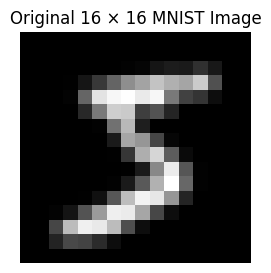

In [5]:
plt.figure(figsize=(3, 3))

plt.imshow(
    image.squeeze(),
    cmap="gray"
)

plt.title("Original 16 × 16 MNIST Image")
plt.axis("off")

plt.show()

## 9. Create the Diffusion Schedule

We use a simple linear \(eta\) schedule for transparency.

In [6]:
number_of_timesteps = 300

beta_start = 0.0001
beta_end = 0.02

betas = torch.linspace(
    beta_start,
    beta_end,
    number_of_timesteps,
    device=device
)

alphas = 1.0 - betas

alpha_bars = torch.cumprod(
    alphas,
    dim=0
)

print("Betas shape:")
print(betas.shape)

print()

print("First beta:")
print(betas[0].item())

print()

print("Last beta:")
print(betas[-1].item())

Betas shape:
torch.Size([300])

First beta:
9.999999747378752e-05

Last beta:
0.019999999552965164


## 10. Inspect the Signal Retention Schedule

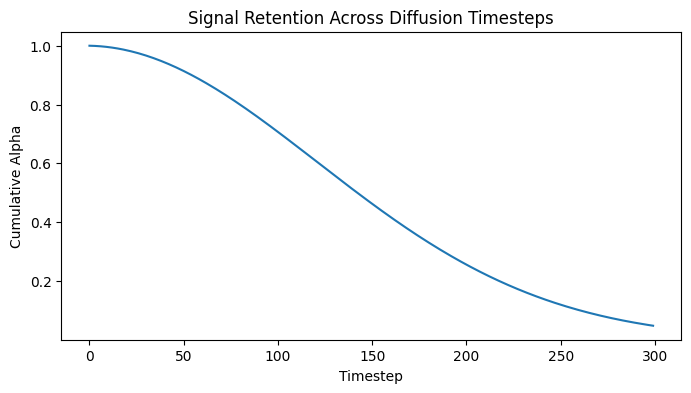

In [7]:
plt.figure(figsize=(8, 4))

plt.plot(
    alpha_bars.cpu()
)

plt.xlabel("Timestep")
plt.ylabel("Cumulative Alpha")
plt.title("Signal Retention Across Diffusion Timesteps")

plt.show()

At early timesteps, most of the original image remains.

At late timesteps, very little original signal remains and the sample approaches pure noise.

## 11. Create the Forward-Noising Function

In [8]:
def add_noise(
    x_0,
    timesteps,
    noise=None
):

    if noise is None:

        noise = torch.randn_like(
            x_0
        )

    alpha_bar_t = alpha_bars[
        timesteps
    ]

    alpha_bar_t = alpha_bar_t.view(
        -1,
        1,
        1,
        1
    )

    noisy_images = (
        torch.sqrt(alpha_bar_t) * x_0
        + torch.sqrt(
            1.0 - alpha_bar_t
        ) * noise
    )

    return noisy_images, noise

## 12. Visualize One Image at Different Timesteps

This is one of the most important visualizations in the notebook because it makes the forward process concrete.

In [9]:
example_image = image.unsqueeze(0)

example_image = example_image.to(device)

selected_timesteps = [
    0,
    30,
    80,
    150,
    220,
    299
]

noisy_versions = []

for timestep in selected_timesteps:

    timestep_tensor = torch.tensor(
        [timestep],
        device=device
    )

    noisy_image, noise = add_noise(
        example_image,
        timestep_tensor
    )

    noisy_versions.append(
        noisy_image.cpu()
    )

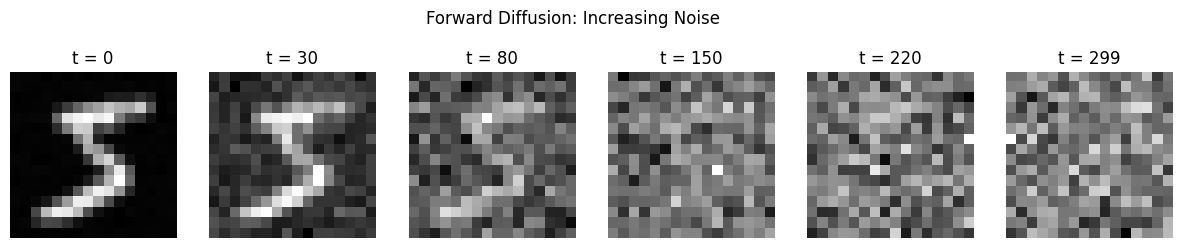

In [10]:
plt.figure(figsize=(15, 3))

for index, noisy_image in enumerate(noisy_versions):

    display_image = noisy_image[
        0,
        0
    ]

    display_image = (
        display_image + 1.0
    ) / 2.0

    plt.subplot(
        1,
        len(noisy_versions),
        index + 1
    )

    plt.imshow(
        display_image,
        cmap="gray"
    )

    plt.title(
        "t = " + str(
            selected_timesteps[index]
        )
    )

    plt.axis("off")

plt.suptitle(
    "Forward Diffusion: Increasing Noise"
)

plt.show()

## 13. What Does the Neural Network Learn?

A common DDPM training strategy asks the neural network to predict the noise \(\epsilon\) that was added.

Training example:

```text
clean image x₀
      ↓
random timestep t
      ↓
random noise ε
      ↓
construct xₜ
      ↓
network receives xₜ and t
      ↓
network predicts ε
```

The loss is usually:

$$
L
=
\mathbb{E}
\left[
\left\|
\epsilon
-
\epsilon_{\theta}(x_t,t)
\right\|^2
\right]
$$

This is a mean-squared error noise-prediction objective.

## 14. Why the Timestep Must Be an Input

The same noisy-looking image can require different denoising behavior depending on the diffusion timestep.

Therefore the model receives:

```text
noisy image xₜ
+
timestep t
```

The timestep is converted to an embedding so the network can condition its prediction on the noise level.

## 15. Sinusoidal Timestep Embedding

We use a sinusoidal embedding inspired by positional encodings.

In [11]:
class SinusoidalTimeEmbedding(nn.Module):

    def __init__(
        self,
        embedding_dimension
    ):
        super().__init__()

        self.embedding_dimension = (
            embedding_dimension
        )


    def forward(self, timesteps):

        half_dimension = (
            self.embedding_dimension // 2
        )

        scale = math.log(
            10000
        ) / (
            half_dimension - 1
        )

        frequencies = torch.exp(
            torch.arange(
                half_dimension,
                device=timesteps.device
            ) * -scale
        )

        angles = timesteps.float().unsqueeze(
            1
        ) * frequencies.unsqueeze(
            0
        )

        embedding = torch.cat(
            [
                torch.sin(angles),
                torch.cos(angles)
            ],
            dim=1
        )

        return embedding

In [12]:
time_embedding = SinusoidalTimeEmbedding(
    embedding_dimension=64
)

example_timesteps = torch.tensor(
    [0, 10, 100, 299],
    device=device
)

embedded_timesteps = time_embedding(
    example_timesteps
)

print("Timestep embedding shape:")
print(embedded_timesteps.shape)

Timestep embedding shape:
torch.Size([4, 64])


## 16. Build a Small Noise-Prediction Network

Modern diffusion models often use U-Net architectures with residual blocks, attention, and sophisticated conditioning.

For learning progression, we first build a smaller convolutional network that clearly shows:

```text
noisy image
   +
time embedding
   ↓
convolutional feature extraction
   ↓
predicted noise
```

This is not intended to reproduce a production-scale diffusion architecture. It is intended to expose the core learning mechanism.

In [13]:
class SmallDiffusionNetwork(nn.Module):

    def __init__(
        self,
        time_embedding_dimension=64
    ):
        super().__init__()

        self.time_embedding = SinusoidalTimeEmbedding(
            time_embedding_dimension
        )

        self.time_layer = nn.Linear(
            time_embedding_dimension,
            32
        )

        self.conv_1 = nn.Conv2d(
            1,
            32,
            kernel_size=3,
            padding=1
        )

        self.conv_2 = nn.Conv2d(
            32,
            64,
            kernel_size=3,
            padding=1
        )

        self.conv_3 = nn.Conv2d(
            64,
            32,
            kernel_size=3,
            padding=1
        )

        self.output_conv = nn.Conv2d(
            32,
            1,
            kernel_size=3,
            padding=1
        )


    def forward(
        self,
        x,
        timesteps
    ):

        time_vector = self.time_embedding(
            timesteps
        )

        time_vector = self.time_layer(
            time_vector
        )

        time_vector = F.relu(
            time_vector
        )

        time_vector = time_vector.view(
            time_vector.size(0),
            32,
            1,
            1
        )

        h = self.conv_1(x)

        h = F.relu(h)

        h = h + time_vector

        h = self.conv_2(h)

        h = F.relu(h)

        h = self.conv_3(h)

        h = F.relu(h)

        predicted_noise = self.output_conv(
            h
        )

        return predicted_noise

## 17. Instantiate and Inspect the Model

In [14]:
diffusion_model = SmallDiffusionNetwork()

diffusion_model = diffusion_model.to(
    device
)

print(diffusion_model)

SmallDiffusionNetwork(
  (time_embedding): SinusoidalTimeEmbedding()
  (time_layer): Linear(in_features=64, out_features=32, bias=True)
  (conv_1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv_2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv_3): Conv2d(64, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (output_conv): Conv2d(32, 1, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
)


In [15]:
total_parameters = 0

for parameter in diffusion_model.parameters():

    total_parameters = (
        total_parameters
        + parameter.numel()
    )

print("Total parameters:")
print(total_parameters)

Total parameters:
39649


## 18. Create the DataLoader

In [16]:
batch_size = 128

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

print("Number of batches:")
print(len(train_loader))

Number of batches:
469


## 19. Follow One Training Batch Through the Process

In [17]:
images, labels = next(iter(train_loader))

images = images.to(device)

current_batch_size = images.size(0)

timesteps = torch.randint(
    low=0,
    high=number_of_timesteps,
    size=(current_batch_size,),
    device=device
)

noisy_images, true_noise = add_noise(
    images,
    timesteps
)

predicted_noise = diffusion_model(
    noisy_images,
    timesteps
)

print("Clean image shape:")
print(images.shape)

print()

print("Timestep shape:")
print(timesteps.shape)

print()

print("Noisy image shape:")
print(noisy_images.shape)

print()

print("True noise shape:")
print(true_noise.shape)

print()

print("Predicted noise shape:")
print(predicted_noise.shape)

Clean image shape:
torch.Size([128, 1, 16, 16])

Timestep shape:
torch.Size([128])

Noisy image shape:
torch.Size([128, 1, 16, 16])

True noise shape:
torch.Size([128, 1, 16, 16])

Predicted noise shape:
torch.Size([128, 1, 16, 16])


## 20. Define the Noise-Prediction Loss

In [18]:
loss = F.mse_loss(
    predicted_noise,
    true_noise
)

print("Initial noise-prediction loss:")
print(loss.item())

Initial noise-prediction loss:
1.0097156763076782


## 21. Train the Diffusion Model

At every batch:

1. choose random timesteps,
2. sample random Gaussian noise,
3. construct noisy images directly,
4. predict the added noise,
5. minimize mean-squared error.

In [19]:
learning_rate = 0.001
number_of_epochs = 10

optimizer = torch.optim.Adam(
    diffusion_model.parameters(),
    lr=learning_rate
)

training_losses = []

In [20]:
for epoch in range(number_of_epochs):

    diffusion_model.train()

    epoch_loss = 0.0

    number_of_batches = 0

    for images, labels in train_loader:

        images = images.to(device)

        current_batch_size = images.size(0)

        timesteps = torch.randint(
            low=0,
            high=number_of_timesteps,
            size=(current_batch_size,),
            device=device
        )

        noisy_images, true_noise = add_noise(
            images,
            timesteps
        )

        predicted_noise = diffusion_model(
            noisy_images,
            timesteps
        )

        loss = F.mse_loss(
            predicted_noise,
            true_noise
        )

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        epoch_loss = (
            epoch_loss + loss.item()
        )

        number_of_batches = (
            number_of_batches + 1
        )

    average_loss = (
        epoch_loss
        / number_of_batches
    )

    training_losses.append(
        average_loss
    )

    print(
        "Epoch:",
        epoch + 1,
        "| Noise Prediction Loss:",
        round(
            average_loss,
            6
        )
    )

Epoch: 1 | Noise Prediction Loss: 0.165293
Epoch: 2 | Noise Prediction Loss: 0.096575
Epoch: 3 | Noise Prediction Loss: 0.088148
Epoch: 4 | Noise Prediction Loss: 0.085381
Epoch: 5 | Noise Prediction Loss: 0.08305
Epoch: 6 | Noise Prediction Loss: 0.080597
Epoch: 7 | Noise Prediction Loss: 0.078957
Epoch: 8 | Noise Prediction Loss: 0.07848
Epoch: 9 | Noise Prediction Loss: 0.077714
Epoch: 10 | Noise Prediction Loss: 0.076837


## 22. Plot Training Loss

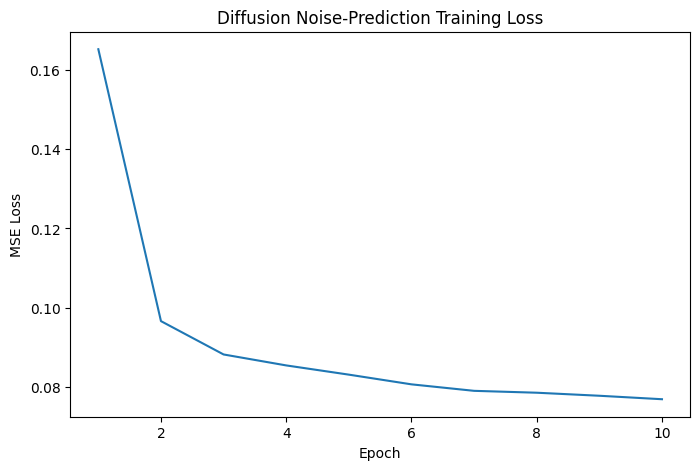

In [21]:
epochs = range(
    1,
    number_of_epochs + 1
)

plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    training_losses
)

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Diffusion Noise-Prediction Training Loss")

plt.show()

## 23. Reverse Diffusion Equation

During generation, we begin with:

$$
x_T \sim \mathcal{N}(0,I)
$$

and repeatedly estimate a less noisy sample.

A simplified DDPM reverse mean can be written using the predicted noise.

The important conceptual sequence is:

```text
pure noise
   ↓
predict noise component
   ↓
remove part of predicted noise
   ↓
add controlled stochasticity
   ↓
repeat
   ↓
generated image
```

## 24. Implement One Reverse Step

This implementation follows the educational DDPM structure. The model predicts the noise, and the scheduler determines how to update the current sample.

In [22]:
def reverse_diffusion_step(
    model,
    x_t,
    timestep
):

    batch_size = x_t.size(0)

    timestep_batch = torch.full(
        (batch_size,),
        timestep,
        device=device,
        dtype=torch.long
    )

    beta_t = betas[
        timestep
    ]

    alpha_t = alphas[
        timestep
    ]

    alpha_bar_t = alpha_bars[
        timestep
    ]

    predicted_noise = model(
        x_t,
        timestep_batch
    )

    coefficient = (
        beta_t
        / torch.sqrt(
            1.0 - alpha_bar_t
        )
    )

    mean = (
        1.0
        / torch.sqrt(alpha_t)
    ) * (
        x_t
        - coefficient * predicted_noise
    )

    if timestep > 0:

        noise = torch.randn_like(
            x_t
        )

        sample = (
            mean
            + torch.sqrt(beta_t) * noise
        )

    else:

        sample = mean

    return sample

## 25. Generate Images Starting From Pure Noise

In [23]:
number_of_generated_images = 16

generated = torch.randn(
    number_of_generated_images,
    1,
    image_size,
    image_size,
    device=device
)

diffusion_model.eval()

with torch.no_grad():

    for timestep in reversed(
        range(number_of_timesteps)
    ):

        generated = reverse_diffusion_step(
            diffusion_model,
            generated,
            timestep
        )

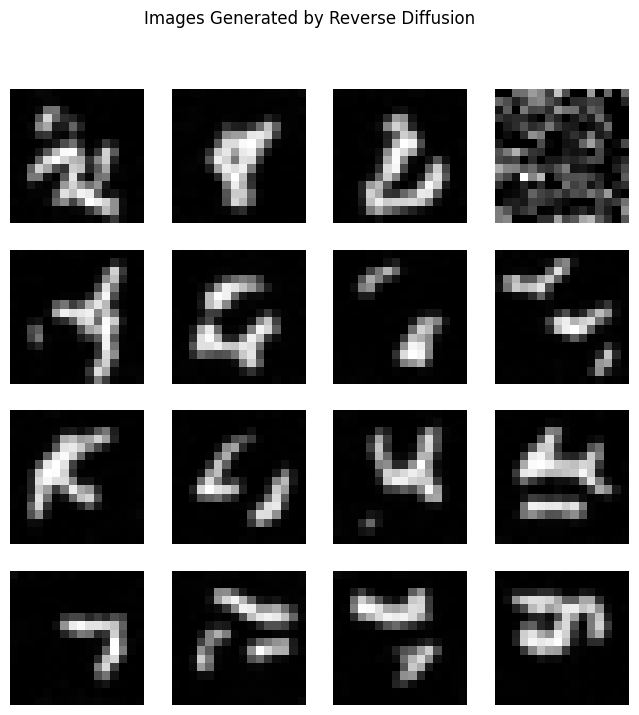

In [24]:
generated_display = generated.cpu()

generated_display = torch.clamp(
    generated_display,
    -1.0,
    1.0
)

generated_display = (
    generated_display + 1.0
) / 2.0

plt.figure(figsize=(8, 8))

for index in range(number_of_generated_images):

    plt.subplot(
        4,
        4,
        index + 1
    )

    plt.imshow(
        generated_display[index].squeeze(),
        cmap="gray"
    )

    plt.axis("off")

plt.suptitle(
    "Images Generated by Reverse Diffusion"
)

plt.show()

## 26. Visualize the Reverse Process

For a final portfolio version, save intermediate samples during reverse diffusion, for example at:

```text
t = 299
t = 240
t = 180
t = 120
t = 60
t = 0
```

and display them side by side.

That visualization is one of the best ways to demonstrate what diffusion generation is actually doing:

```text
noise → rough structure → digit-like structure → cleaner digit
```

## 27. DDPM vs DDIM

### DDPM

- stochastic reverse process,
- typically many sampling steps,
- strong theoretical connection to the diffusion formulation.

### DDIM

- can use a more deterministic sampling path,
- often supports fewer sampling steps,
- can accelerate generation.

The training objective can remain closely related even when the sampling procedure changes.

## 28. Classifier-Free Guidance

Modern conditional diffusion systems often strengthen conditioning using **classifier-free guidance**.

Conceptually, the model combines:

- an unconditional noise prediction,
- a conditional noise prediction.

A guidance scale controls how strongly generation follows the condition.

This is important for understanding text-conditioned diffusion models, even though it is beyond the minimal MNIST implementation in this notebook.

## 29. Latent Diffusion

Pixel-space diffusion can be expensive because the model repeatedly processes high-dimensional images.

Latent diffusion introduces another idea:

```text
image
  ↓
encoder
  ↓
compressed latent representation
  ↓
diffusion in latent space
  ↓
decoder
  ↓
image
```

This connects generative diffusion back to the representation-learning ideas from the Autoencoder and VAE sections.

## 30. Why Production Diffusion Models Use U-Nets

A U-Net provides:

- multi-scale feature processing,
- downsampling and upsampling,
- skip connections,
- strong spatial detail recovery.

Modern diffusion networks may also include:

- residual blocks,
- attention,
- cross-attention,
- text conditioning,
- sophisticated noise schedules.

The small network used here intentionally exposes the diffusion objective before those architectural complications are introduced.

## 31. Compare VAE, GAN, and Diffusion

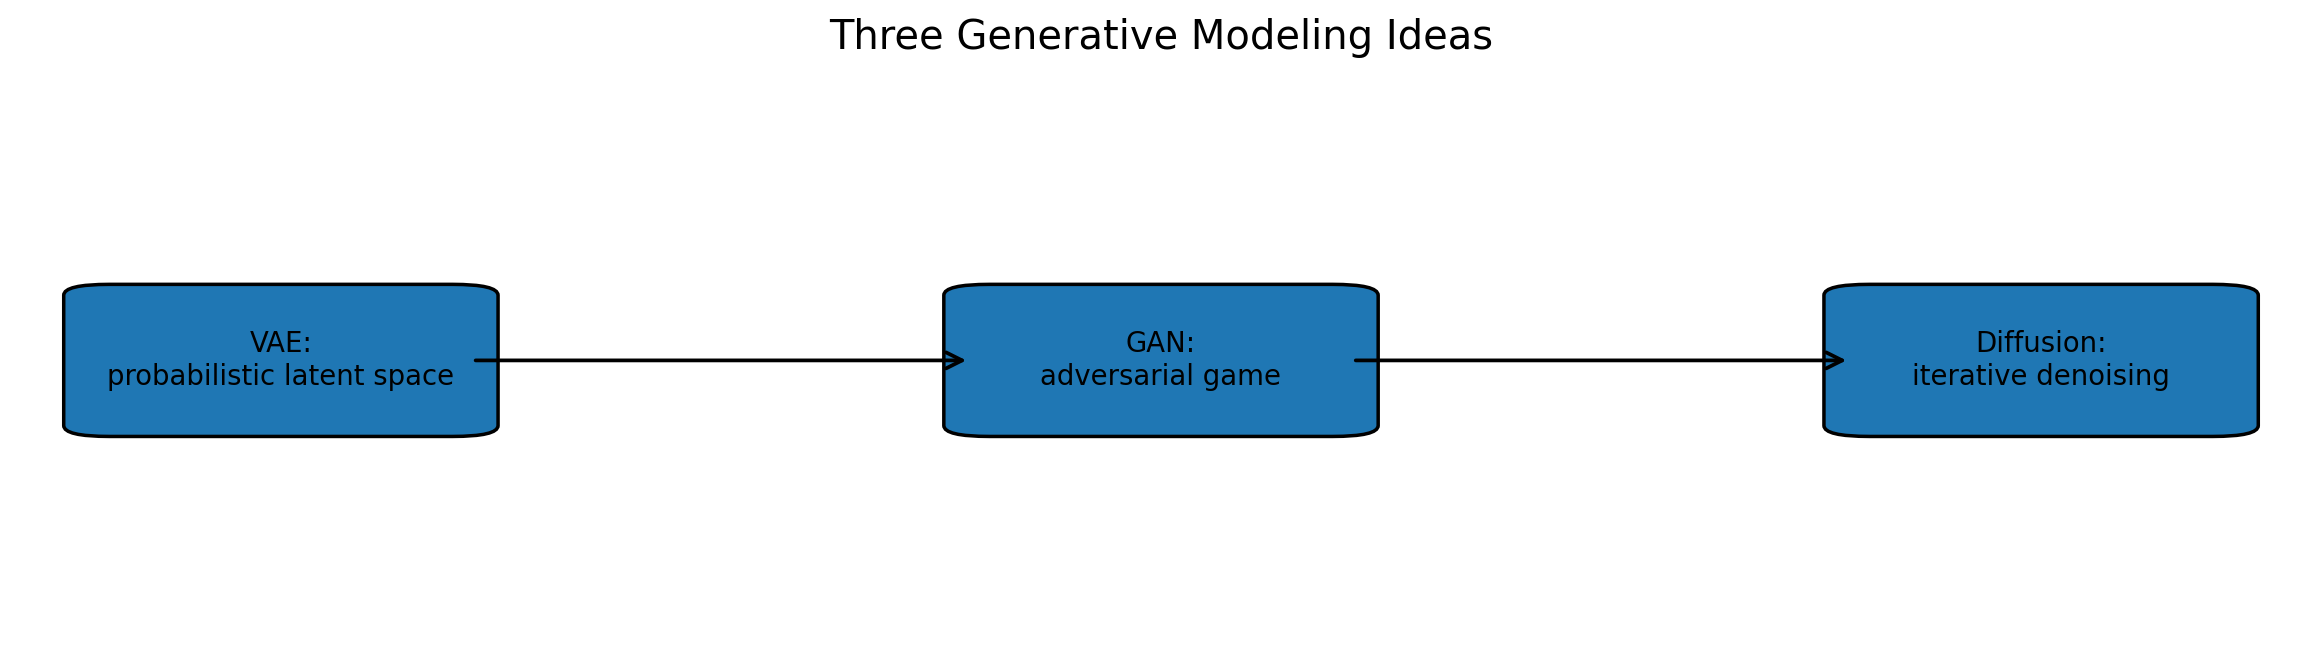

| Model | Core Learning Idea | Main Strength | Main Challenge |
|---|---|---|---|
| VAE | Probabilistic latent representation | Smooth latent space and stable training | Often softer outputs |
| GAN | Generator-discriminator competition | Sharp generation | Training instability and mode collapse |
| Diffusion | Learn iterative denoising | High-quality stable generation | Slow sampling and high computation |

## 32. A More Careful Comparison

### Latent representation

VAE explicitly models a latent distribution.

GAN usually samples from a simple latent prior but does not require an encoder in the basic formulation.

Diffusion can operate in pixel space or latent space.

### Training stability

VAE training is usually straightforward.

GAN training is a two-player optimization problem and can be unstable.

Diffusion training is usually stable because it can be formulated as supervised noise prediction.

### Sampling speed

VAE and GAN generation can happen in one decoder/generator pass.

Diffusion usually requires many iterative denoising steps.

This is a major practical trade-off.

## 33. Suggested Experiment

For deeper analysis, keep one data domain fixed and compare:

```text
VAE
GAN
Diffusion
```

on:

- visual quality,
- training stability,
- generation speed,
- latent controllability,
- parameter count,
- inference steps.

Avoid claiming that one model is universally "best." The goal is to show that each family makes different modeling and computational trade-offs.

## 34. Limitations of This Educational Diffusion Model

- very small image size,
- simple convolutional architecture,
- basic linear noise schedule,
- no U-Net,
- no attention,
- no conditioning,
- relatively few training epochs,
- no FID or other large-scale image-generation metric.

These limitations are deliberate. The notebook first demonstrates the mechanics of diffusion clearly before introducing production-level complexity.

## 35. Final Learning Progression

The three notebooks in this folder now form one coherent path:

```text
Autoencoder knowledge
      ↓
Variational Autoencoder
      ↓
probabilistic latent generation
      ↓
GAN
      ↓
adversarial generation
      ↓
Diffusion
      ↓
iterative denoising generation
```

This is the intended transition from earlier representation-learning material into modern generative deep learning.

## 36. Key Takeaways

- Diffusion models define a forward noising process and learn a reverse denoising process.
- A noise schedule controls how quickly information is destroyed.
- The closed-form forward equation allows direct sampling of any noisy timestep.
- A common DDPM objective trains the neural network to predict the added noise.
- Generation begins from Gaussian noise and repeatedly applies reverse denoising steps.
- Timestep embeddings tell the network how noisy the current sample is.
- DDIM, classifier-free guidance, latent diffusion, U-Nets, and attention extend the same core principles into modern systems.